# NOAA Wave Data Analysis - Station 51002  

4 Plot analysis for understanding different params in spectral wave data

In [54]:

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime 

file_path = '../51002/51002.spec' 

# Read the first two lines to get column names and units
with open(file_path, 'r') as f:
    header_line = f.readline().strip()
    units_line = f.readline().strip()

# Remove # prefix and split into column names
column_names = header_line.replace('#', '').split()
units = units_line.replace('#', '').split()

# Create a dictionary mapping column names to units
column_units = {name: unit for name, unit in zip(column_names, units)}

# Read the data using pandas, skipping the first two rows (header and units)
df = pd.read_csv(file_path, 
                skiprows=2, 
                sep=r'\s+',
                names=column_names)

# Create single datetime column for easier plotting, set in GMT timezone
df['datetime'] = pd.to_datetime({
    'year': df['YY'],
    'month': df['MM'],
    'day': df['DD'],
    'hour': df['hh'],
        'minute': df['mm']
    })

In [ ]:

# Display basic information about the data / set up plot styling
print("Data Overview:")
print(df.head())

print("\nData Statistics:")
print(df.describe())


Data Overview:
     YY  MM  DD  hh  mm  WVHT  SwH  SwP  WWH  WWP  SwD WWD STEEPNESS  APD  \
0  2025   5  18  16  10   2.4  1.3  9.1  2.0  6.7    E   E   AVERAGE  6.0   
1  2025   5  18  15  40   2.3  1.5  8.3  1.8  7.1    E   E     STEEP  6.1   
2  2025   5  18  15  10   2.3  1.5  9.1  1.7  6.7  ENE   E   AVERAGE  6.0   
3  2025   5  18  14  40   2.3  1.5  9.1  1.7  7.1    E   E   AVERAGE  5.9   
4  2025   5  18  14  10   2.4  1.7  8.3  1.7  4.3    E   E     STEEP  6.3   

   MWD            datetime  
0   86 2025-05-18 16:10:00  
1   87 2025-05-18 15:40:00  
2   77 2025-05-18 15:10:00  
3   81 2025-05-18 14:40:00  
4   82 2025-05-18 14:10:00  

Data Statistics:
           YY           MM           DD           hh           mm  \
count  2176.0  2176.000000  2176.000000  2176.000000  2176.000000   
mean   2025.0     4.388327    13.746783    11.443474    24.986213   
min    2025.0     4.000000     1.000000     0.000000    10.000000   
25%    2025.0     4.000000     7.000000     5.000000  

<Figure size 200x400 with 0 Axes>

<Figure size 200x400 with 0 Axes>

## Wave Heights   



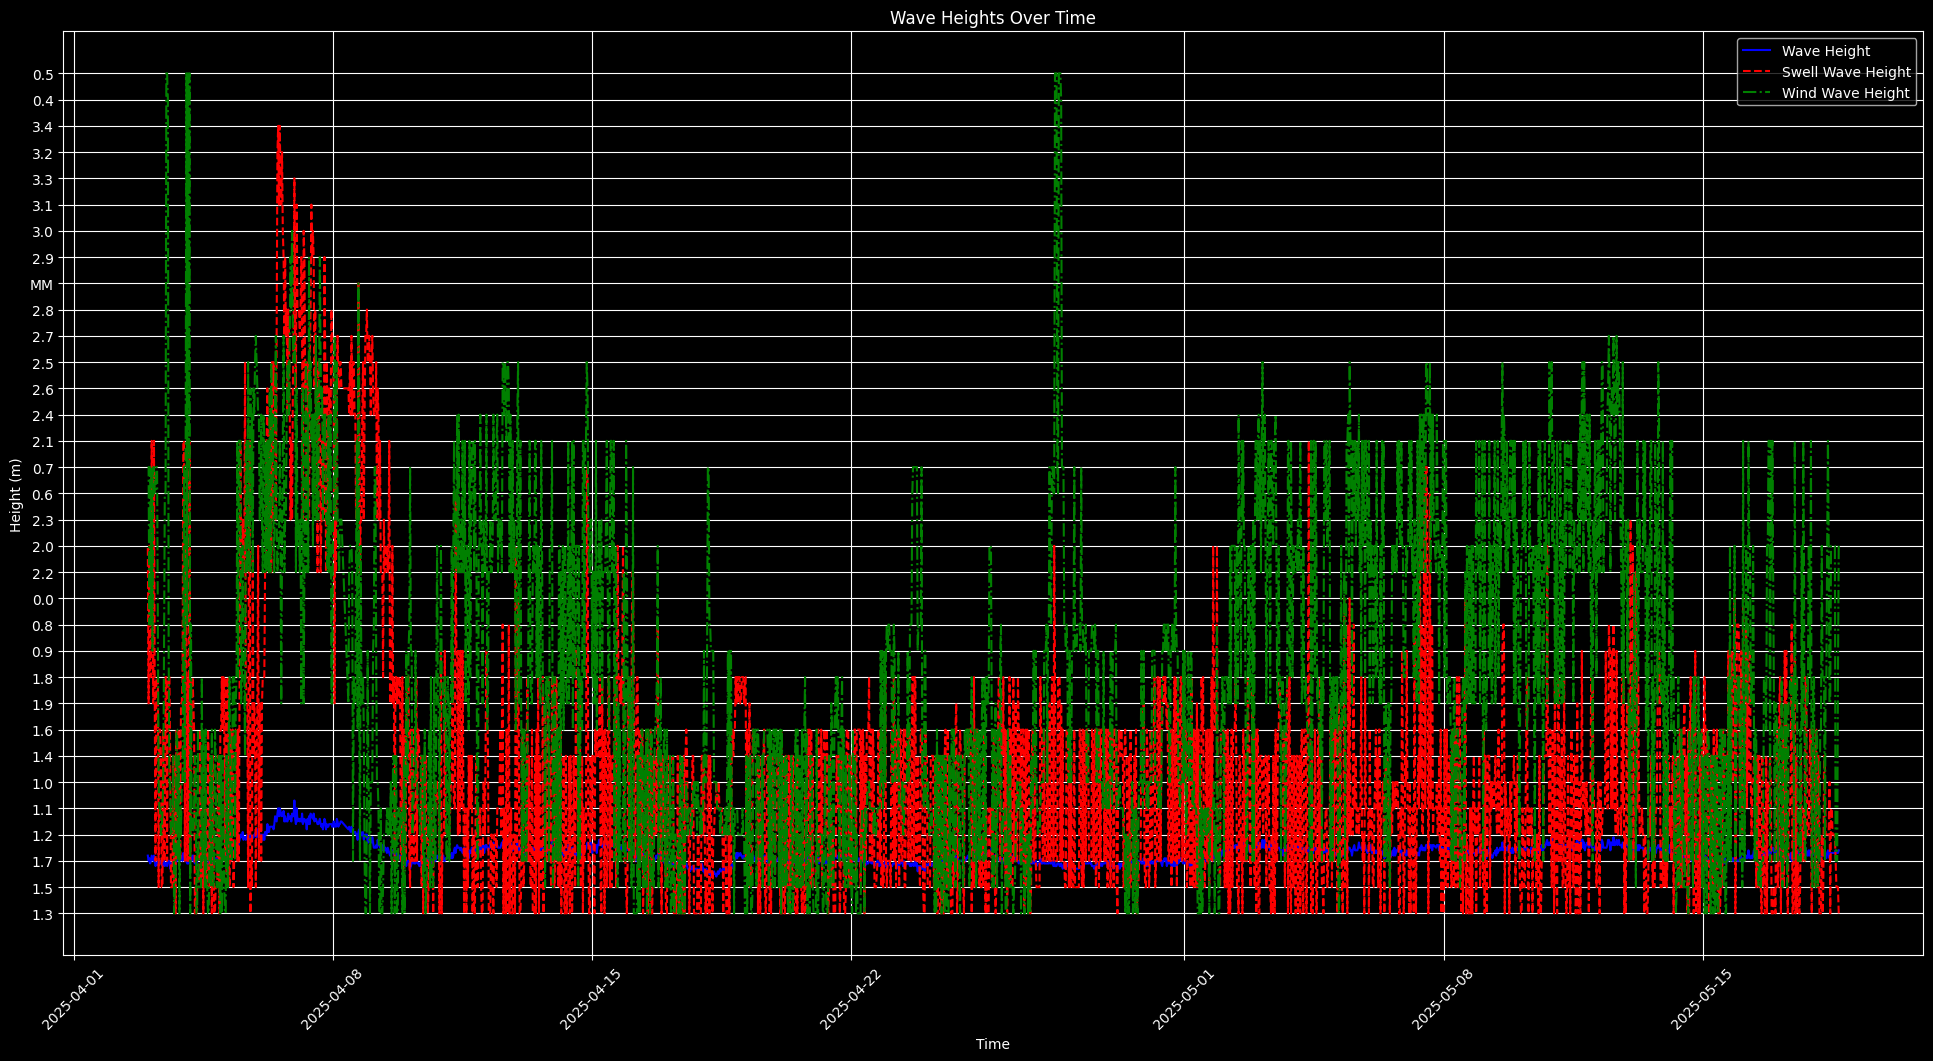

In [108]:

# Plot 1: Wave Height Time Series 
plt.figure(figsize=(24, 12))
plt.plot(df['datetime'], df['WVHT'], 'b-', label='Wave Height')
plt.plot(df['datetime'], df['SwH'], 'r--', label='Swell Wave Height')
plt.plot(df['datetime'], df['WWH'], 'g-.', label='Wind Wave Height')
plt.xlabel('Time')
plt.ylabel(f'Height ({column_units["WVHT"]})')
plt.title('Wave Heights Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45) 
plt.show()

### Wave Period Time 

Wave period times represent the interval between

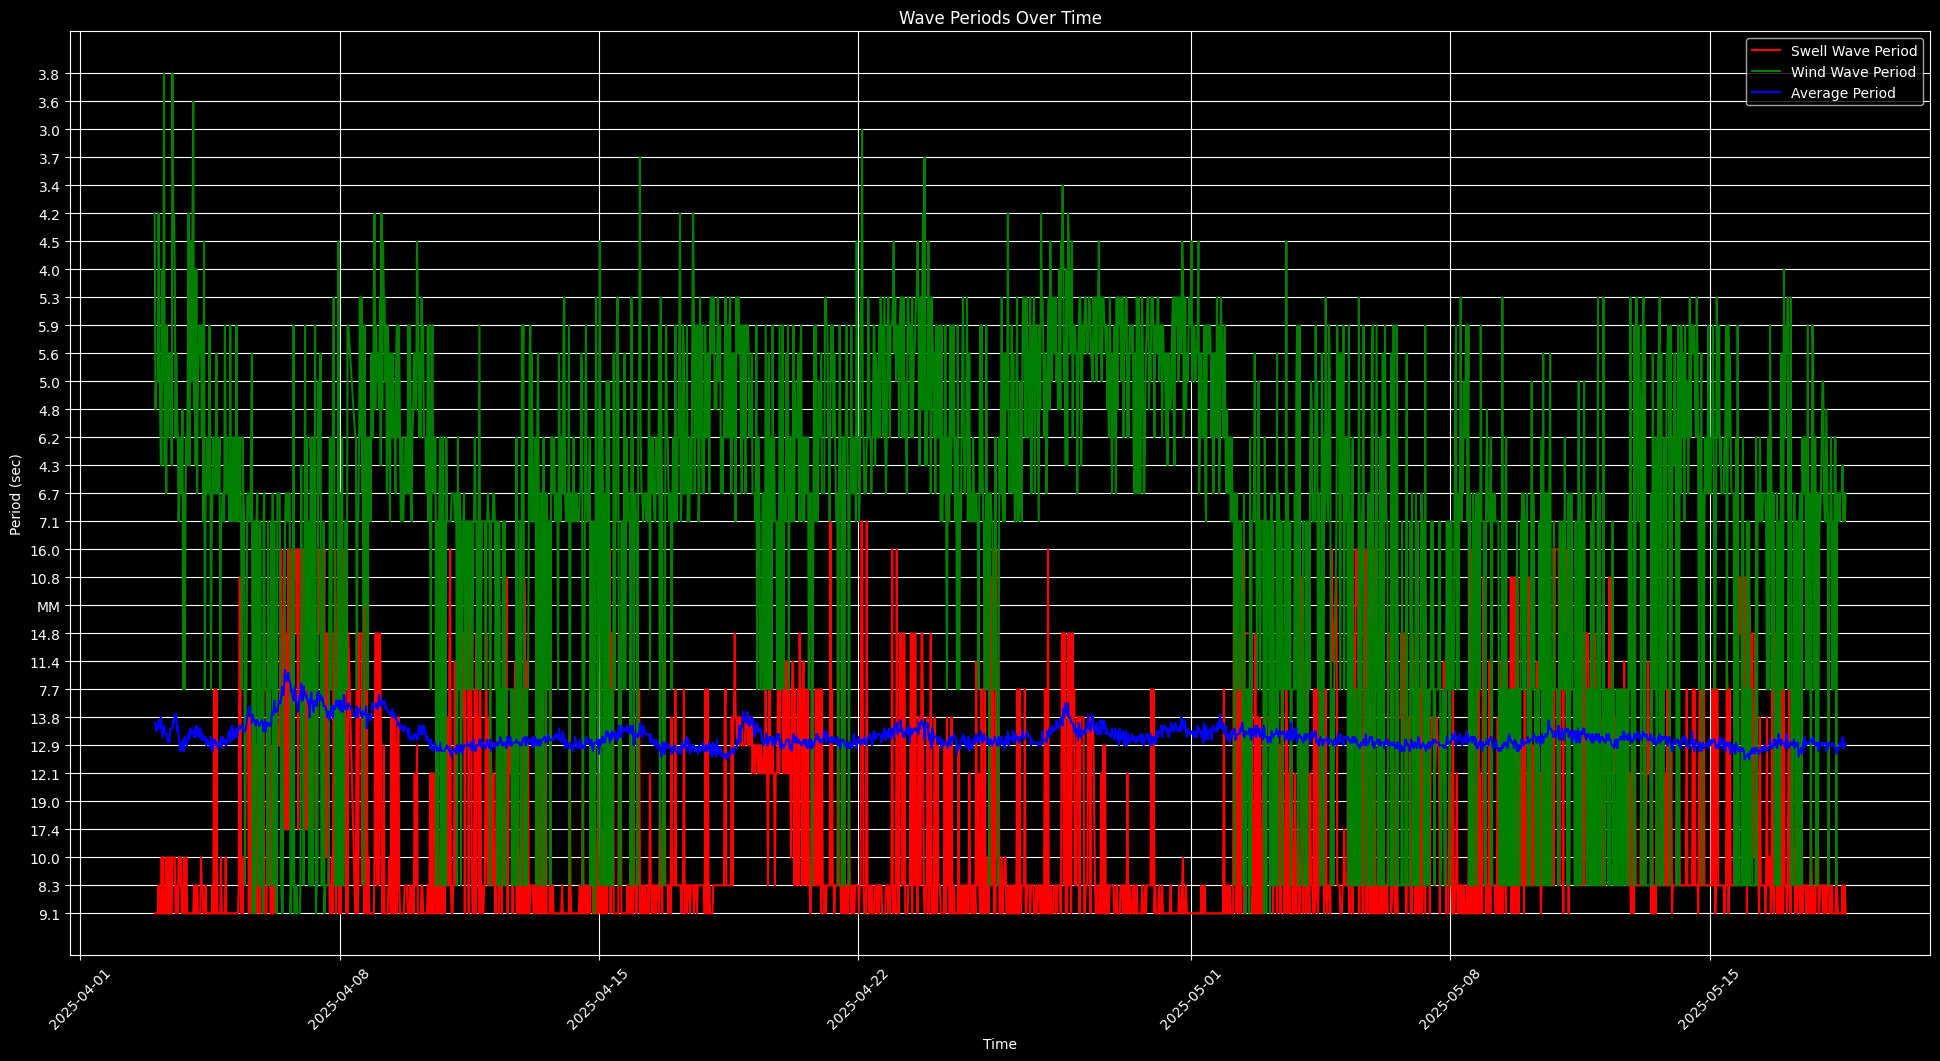

In [109]:
# Plot 2: Wave Period Time Series
plt.figure(figsize=(24, 12))
plt.plot(df['datetime'], df['SwP'], 'r-', label='Swell Wave Period')
plt.plot(df['datetime'], df['WWP'], 'g-', label='Wind Wave Period')
plt.plot(df['datetime'], df['APD'], 'b-', label='Average Period')
plt.xlabel('Time')
plt.ylabel(f'Period ({column_units["SwP"]})')
plt.title('Wave Periods Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  
plt.show()

(array([20179., 20186., 20193., 20200., 20209., 20216., 20223.]),
 [Text(20179.0, 0, '2025-04-01'),
  Text(20186.0, 0, '2025-04-08'),
  Text(20193.0, 0, '2025-04-15'),
  Text(20200.0, 0, '2025-04-22'),
  Text(20209.0, 0, '2025-05-01'),
  Text(20216.0, 0, '2025-05-08'),
  Text(20223.0, 0, '2025-05-15')])

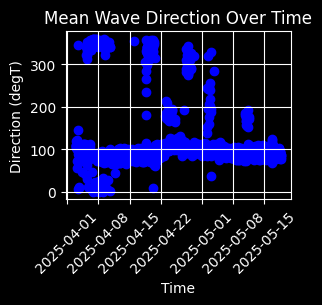

In [110]:
# Plot 3: Wave Direction
plt.figure(figsize=(24, 12))
plt.scatter(df['datetime'], df['MWD'], c='blue', label='Mean Wave Direction')
plt.xlabel('Time')
plt.ylabel(f'Direction ({column_units["MWD"]})')
plt.title('Mean Wave Direction Over Time')
plt.grid(True) 
plt.xticks(rotation=45) 
plt.show()

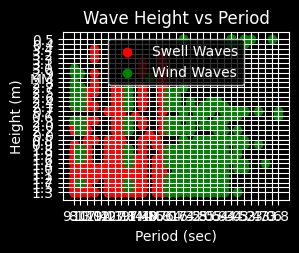

In [111]:
# Plot 4: Wave Height vs Period
plt.figure(figsize=(24, 12))
plt.scatter(df['SwP'], df['SwH'], color='red', label='Swell Waves')
plt.scatter(df['WWP'], df['WWH'], color='green', label='Wind Waves')
plt.xlabel(f'Period ({column_units["SwP"]})')
plt.ylabel(f'Height ({column_units["WVHT"]})')
plt.title('Wave Height vs Period')
plt.legend()
plt.grid(True) 
plt.show()